In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from ase.io import read  # Assuming you are using ASE to read the extxyz file

# ==========================================
# CONFIGURATION VARIABLES
# ==========================================
DATASET_SIZE = 10000  # Set to an integer to limit frames, or None to read ALL frames
BATCH_SIZE = 2000    # Number of frames to process in a single vectorized batch

# ==========================================
# 1. READ TRAJECTORY (With Size Control)
# ==========================================
# If DATASET_SIZE is set, we slice the index (e.g., ":10000") to avoid loading unneeded frames into RAM
slice_index = f":{DATASET_SIZE}" if DATASET_SIZE is not None else ":"
frames = read("valid.extxyz", index=slice_index)
print(f"Extracted {len(frames)} total trajectory frames based on DATASET_SIZE.")

# Extract atomic configurations into a unified 3D NumPy array
trajectory_points = np.array([frame.get_positions() for frame in frames])
print("Trajectory shape (Frames, Atoms, Coordinates):", trajectory_points.shape)

# ==========================================
# 2. BATCHED ANALYSIS FUNCTION
# ==========================================
def analyze_atom_distances_batched(trajectory_coords, batch_size=1000):
    """
    Computes mean pairwise distances across a trajectory using memory-safe batching.

    Parameters:
    -----------
    trajectory_coords : np.ndarray
        Shape (T, N, 3) where T=frames, N=atoms, 3=XYZ coordinates.
    batch_size : int
        Number of frames processed per batch.
    """
    num_frames, num_atoms, _ = trajectory_coords.shape
    mean_distance_matrix = np.zeros((num_atoms, num_atoms))

    # Process the trajectory in chunks of 'batch_size'
    for i in range(0, num_frames, batch_size):
        # Slice the current batch of frames
        batch = trajectory_coords[i : i + batch_size]

        # Vectorized pairwise distance calculation for the entire batch:
        # Subtracting shapes: (B, N, 1, 3) - (B, 1, N, 3) -> Results in (B, N, N, 3)
        diff = batch[:, :, np.newaxis, :] - batch[:, np.newaxis, :, :]

        # Calculate Euclidean norm along the coordinate axis (-1) -> Results in (B, N, N)
        dist = np.linalg.norm(diff, axis=-1)

        # Sum distances across the batch dimension (axis 0) and accumulate
        mean_distance_matrix += np.sum(dist, axis=0)

    # Divide by total frames to get the true mean value across the trajectory
    mean_distance_matrix /= num_frames

    # For each atom, sort the indices of other atoms by distance (ascending order)
    sorted_atom_indices = np.argsort(mean_distance_matrix, axis=1)

    return mean_distance_matrix, sorted_atom_indices

# ==========================================
# 3. RUN THE ANALYSIS
# ==========================================
means, sorted_idx = analyze_atom_distances_batched(trajectory_points, batch_size=BATCH_SIZE)

print("\n--- Analysis Completed ---")
print("Mean distance matrix shape:", means.shape)
print("Sorted indices matrix shape:", sorted_idx.shape)

# Quick validation check on Atom 0:
print("\nAtom 0 closest atoms (ordered indices):")
print(sorted_idx[0])
print("Corresponding mean distances:")
print(np.take_along_axis(means[0], sorted_idx[0], axis=0))

Extracted 541 total trajectory frames based on DATASET_SIZE.
Trajectory shape (Frames, Atoms, Coordinates): (541, 100, 3)

--- Analysis Completed ---
Mean distance matrix shape: (100, 100)
Sorted indices matrix shape: (100, 100)

Atom 0 closest atoms (ordered indices):
[ 0 12 16  4 18 78 80 72 43 31 24 76 49 74 26 29 35 23 87 70  8 82 33 51
 98 21 66 65 89 37 60 39 47 52 91 96 68 53 45 10 85 41 92  2 14 64 88 97
 93 56 94 81 62 48 25 15 77 44  6 84 61 36 57 55  5 73 69 20 58 40 32 28
  9 17  3  1 19 11 54 30 75 59 22 34 79 38 27 71  7 42 50 13 83 86 99 63
 67 90 95 46]
Corresponding mean distances:
[ 0.          3.13661002  3.20024676  3.22110572  3.25721366  3.82680651
  3.95505622  4.11510549  4.14018309  4.25260397  4.46649722  4.61309265
  4.64442584  4.65598145  4.68958717  4.70518166  4.77102836  4.85315681
  5.00573636  5.25560325  5.2622736   5.28525575  5.39937445  5.44643649
  5.53917706  5.60936556  5.62978021  5.67659693  5.68254087  5.69066005
  5.71775176  5.80973679  5.8

In [ ]:
! pip install ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 75.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from ase.io import read

# ==========================================
# CONFIGURATION VARIABLES
# ==========================================
DATASET_SIZE = 10000  # Set to an integer to limit frames, or None to read ALL frames
BATCH_SIZE = 2000    # Number of frames to process in a single vectorized batch

# ==========================================
# 1. READ TRAJECTORY & EXTRACT SPECIES
# ==========================================
slice_index = f":{DATASET_SIZE}" if DATASET_SIZE is not None else ":"
frames = read("valid.extxyz", index=slice_index)
print(f"Extracted {len(frames)} total trajectory frames based on DATASET_SIZE.")

# Extract chemical species (e.g., ['H', 'O', 'C', ...])
atom_species = frames[0].get_chemical_symbols()
num_atoms = len(atom_species)

# Extract atomic configurations into a unified 3D NumPy array
trajectory_points = np.array([frame.get_positions() for frame in frames])
print("Trajectory shape (Frames, Atoms, Coordinates):", trajectory_points.shape)

# ==========================================
# 2. BATCHED ANALYSIS FUNCTION
# ==========================================
def analyze_atom_distances_batched(trajectory_coords, batch_size=1000):
    num_frames, num_atoms, _ = trajectory_coords.shape
    mean_distance_matrix = np.zeros((num_atoms, num_atoms))

    for i in range(0, num_frames, batch_size):
        batch = trajectory_coords[i : i + batch_size]
        diff = batch[:, :, np.newaxis, :] - batch[:, np.newaxis, :, :]
        dist = np.linalg.norm(diff, axis=-1)
        mean_distance_matrix += np.sum(dist, axis=0)

    mean_distance_matrix /= num_frames
    sorted_atom_indices = np.argsort(mean_distance_matrix, axis=1)

    return mean_distance_matrix, sorted_atom_indices

# ==========================================
# 3. RUN THE ANALYSIS
# ==========================================
means, sorted_idx = analyze_atom_distances_batched(trajectory_points, batch_size=BATCH_SIZE)

print("\n" + "="*80)
print("ANALYSIS COMPLETED - PRINTING MATRICES WITH ATOMIC SPECIES")
print("="*80)

# ==========================================
# 4. PRINTING MATRIX 1: FULL PAIRWISE MATRIX
# ==========================================
print("\n--- 1. PAIRWISE MEAN DISTANCE MATRIX ---")
print("Format: [Source Atom] -> [Target Atom (Species): Distance, ...]\n")

for i in range(num_atoms):
    # Prefix the row with the source atom index and its chemical symbol
    row_prefix = f"Atom {i:03d} ({atom_species[i]}) -> "

    # Map target species and target indices to their corresponding mean distances
    row_values = [
        f"Atom {j:03d} ({atom_species[j]}): {means[i, j]:.3f} Å"
        for j in range(num_atoms)
    ]

    # Print the clean joined string for the row
    print(row_prefix + ", ".join(row_values))

# ==========================================
# 5. PRINTING MATRIX 2: SORTED NEIGHBORS
# ==========================================
print("\n" + "-"*80)
print("\n--- 2. SORTED NEIGHBORS MATRIX (Closest to Farthest) ---")
print("Format: [Source Atom] -> [1st Closest (Species) (Dist) | 2nd Closest ...]\n")

for i in range(num_atoms):
    row_prefix = f"Atom {i:03d} ({atom_species[i]}) neighbors -> "

    # sorted_idx[i] contains indices ordered by proximity.
    # We slice [1:] to skip over sorted_idx[i][0], which is always the atom itself (distance 0.0)
    sorted_neighbors = [
        f"Atom {nb_idx:03d} ({atom_species[nb_idx]}) [{means[i, nb_idx]:.3f} Å]"
        for nb_idx in sorted_idx[i][1:]
    ]

    print(row_prefix + " | ".join(sorted_neighbors))

Extracted 541 total trajectory frames based on DATASET_SIZE.
Trajectory shape (Frames, Atoms, Coordinates): (541, 100, 3)

ANALYSIS COMPLETED - PRINTING MATRICES WITH ATOMIC SPECIES

--- 1. PAIRWISE MEAN DISTANCE MATRIX ---
Format: [Source Atom] -> [Target Atom (Species): Distance, ...]

Atom 000 (Sn) -> Atom 000 (Sn): 0.000 Å, Atom 001 (Sn): 10.644 Å, Atom 002 (Sn): 6.346 Å, Atom 003 (Sn): 10.383 Å, Atom 004 (I): 3.221 Å, Atom 005 (I): 7.826 Å, Atom 006 (I): 7.391 Å, Atom 007 (I): 13.524 Å, Atom 008 (I): 5.262 Å, Atom 009 (I): 10.251 Å, Atom 010 (I): 6.131 Å, Atom 011 (I): 11.345 Å, Atom 012 (I): 3.137 Å, Atom 013 (I): 13.768 Å, Atom 014 (I): 6.399 Å, Atom 015 (I): 7.246 Å, Atom 016 (I): 3.200 Å, Atom 017 (I): 10.351 Å, Atom 018 (I): 3.257 Å, Atom 019 (I): 10.716 Å, Atom 020 (N): 8.289 Å, Atom 021 (N): 5.609 Å, Atom 022 (N): 13.000 Å, Atom 023 (N): 4.853 Å, Atom 024 (N): 4.466 Å, Atom 025 (N): 7.231 Å, Atom 026 (N): 4.690 Å, Atom 027 (N): 13.284 Å, Atom 028 (H): 8.932 Å, Atom 029 (H):

In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from ase.io import read

# ==========================================
# CONFIGURATION VARIABLES
# ==========================================
DATASET_SIZE = 10000  # Set to an integer to limit frames, or None to read ALL frames
BATCH_SIZE = 2000    # Number of frames to process in a single vectorized batch

# ==========================================
# 1. READ TRAJECTORY & EXTRACT SPECIES
# ==========================================
slice_index = f":{DATASET_SIZE}" if DATASET_SIZE is not None else ":"
frames = read("valid.extxyz", index=slice_index)
print(f"Extracted {len(frames)} total trajectory frames based on DATASET_SIZE.")

# Extract chemical species (e.g., ['H', 'O', 'C', ...])
atom_species = frames[0].get_chemical_symbols()
num_atoms = len(atom_species)

# Extract atomic configurations into a unified 3D NumPy array
trajectory_points = np.array([frame.get_positions() for frame in frames])
print("Trajectory shape (Frames, Atoms, Coordinates):", trajectory_points.shape)

# ==========================================
# 2. BATCHED ANALYSIS FUNCTION
# ==========================================
def analyze_atom_distances_batched(trajectory_coords, batch_size=1000):
    num_frames, num_atoms, _ = trajectory_coords.shape
    mean_distance_matrix = np.zeros((num_atoms, num_atoms))

    for i in range(0, num_frames, batch_size):
        batch = trajectory_coords[i : i + batch_size]
        diff = batch[:, :, np.newaxis, :] - batch[:, np.newaxis, :, :]
        dist = np.linalg.norm(diff, axis=-1)
        mean_distance_matrix += np.sum(dist, axis=0)

    mean_distance_matrix /= num_frames
    sorted_atom_indices = np.argsort(mean_distance_matrix, axis=1)

    return mean_distance_matrix, sorted_atom_indices

# ==========================================
# 3. RUN THE ANALYSIS
# ==========================================
means, sorted_idx = analyze_atom_distances_batched(trajectory_points, batch_size=BATCH_SIZE)

print("\n" + "="*80)
print("ANALYSIS COMPLETED - PRINTING DATA")
print("="*80)

# ==========================================
# 4. PRINTING MATRIX 1: FULL PAIRWISE MATRIX
# ==========================================
print("\n--- 1. PAIRWISE MEAN DISTANCE MATRIX ---")
for i in range(num_atoms):
    row_prefix = f"Atom {i:03d} ({atom_species[i]}) -> "
    row_values = [f"Atom {j:03d} ({atom_species[j]}): {means[i, j]:.3f} Å" for j in range(num_atoms)]
    print(row_prefix + ", ".join(row_values))

# ==========================================
# 5. PRINTING MATRIX 2: SORTED NEIGHBORS
# ==========================================
print("\n" + "-"*80)
print("\n--- 2. SORTED NEIGHBORS MATRIX (Closest to Farthest) ---")
for i in range(num_atoms):
    row_prefix = f"Atom {i:03d} ({atom_species[i]}) neighbors -> "
    sorted_neighbors = [
        f"Atom {nb_idx:03d} ({atom_species[nb_idx]}) [{means[i, nb_idx]:.3f} Å]"
        for nb_idx in sorted_idx[i][1:]  # Slice [1:] to skip self
    ]
    print(row_prefix + " | ".join(sorted_neighbors))

# ==========================================
# 6. NEW: SUMMARY RECAP BY ATOMIC SPECIES
# ==========================================
print("\n" + "="*80)
print("--- 3. SPECIES-LEVEL ANALYSIS RECAP ---")
print("="*80)

# Find all unique chemical elements present in the system (e.g., ['C', 'H', 'O'])
unique_species = sorted(list(set(atom_species)))

for spec in unique_species:
    # Get indices of all atoms that belong to the current species
    spec_indices = [k for k, s in enumerate(atom_species) if s == spec]

    # --- Task A: Mean of the top 10 closest distances ---
    all_top10_dists = []
    for idx in spec_indices:
        # sorted_idx[idx, 1:11] gives the 10 closest atom indices (excluding self at index 0)
        top10_neighbors = sorted_idx[idx, 1:11]
        all_top10_dists.extend(means[idx, top10_neighbors])

    mean_top10 = np.mean(all_top10_dists)

    # --- Task B: Find the overall closest neighbor species ---
    closest_species_name = None
    closest_species_avg_dist = float('inf')

    for target_spec in unique_species:
        # Get indices of the target species we want to test against
        target_indices = [k for k, s in enumerate(atom_species) if s == target_spec]

        dists_to_target_type = []
        for idx in spec_indices:
            # Exclude the source atom itself if we are comparing a species to itself (e.g., H to H)
            valid_targets = [t for t in target_indices if t != idx]

            if valid_targets:
                # Find the single closest atom of this target species type
                closest_atom_dist = np.min(means[idx, valid_targets])
                dists_to_target_type.append(closest_atom_dist)

        # Calculate the average minimum distance to this target species type
        if dists_to_target_type:
            avg_min_dist = np.mean(dists_to_target_type)

            # If it's shorter than what we've seen before, update our closest species tracker
            if avg_min_dist < closest_species_avg_dist:
                closest_species_avg_dist = avg_min_dist
                closest_species_name = target_spec

    # Print the clean summary block for this element type
    print(f"Species [{spec}] ({len(spec_indices)} atoms found):")
    print(f"  -> Mean of the top 10 closest neighbor distances: {mean_top10:.4f} Å")
    print(f"  -> Closest chemical species on average:          {closest_species_name} (Avg Min Distance: {closest_species_avg_dist:.4f} Å)")
    print("-"*50)

Extracted 541 total trajectory frames based on DATASET_SIZE.
Trajectory shape (Frames, Atoms, Coordinates): (541, 100, 3)

ANALYSIS COMPLETED - PRINTING DATA

--- 1. PAIRWISE MEAN DISTANCE MATRIX ---
Atom 000 (Sn) -> Atom 000 (Sn): 0.000 Å, Atom 001 (Sn): 10.644 Å, Atom 002 (Sn): 6.346 Å, Atom 003 (Sn): 10.383 Å, Atom 004 (I): 3.221 Å, Atom 005 (I): 7.826 Å, Atom 006 (I): 7.391 Å, Atom 007 (I): 13.524 Å, Atom 008 (I): 5.262 Å, Atom 009 (I): 10.251 Å, Atom 010 (I): 6.131 Å, Atom 011 (I): 11.345 Å, Atom 012 (I): 3.137 Å, Atom 013 (I): 13.768 Å, Atom 014 (I): 6.399 Å, Atom 015 (I): 7.246 Å, Atom 016 (I): 3.200 Å, Atom 017 (I): 10.351 Å, Atom 018 (I): 3.257 Å, Atom 019 (I): 10.716 Å, Atom 020 (N): 8.289 Å, Atom 021 (N): 5.609 Å, Atom 022 (N): 13.000 Å, Atom 023 (N): 4.853 Å, Atom 024 (N): 4.466 Å, Atom 025 (N): 7.231 Å, Atom 026 (N): 4.690 Å, Atom 027 (N): 13.284 Å, Atom 028 (H): 8.932 Å, Atom 029 (H): 4.705 Å, Atom 030 (H): 12.095 Å, Atom 031 (H): 4.253 Å, Atom 032 (H): 8.913 Å, Atom 033 

In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from ase.io import read

# ==========================================
# CONFIGURATION VARIABLES
# ==========================================
DATASET_SIZE = 10000  # Set to an integer to limit frames, or None to read ALL frames
BATCH_SIZE = 2000    # Number of frames to process in a single vectorized batch

# ==========================================
# 1. READ TRAJECTORY & EXTRACT SPECIES
# ==========================================
slice_index = f":{DATASET_SIZE}" if DATASET_SIZE is not None else ":"
frames = read("valid.extxyz", index=slice_index)
print(f"Extracted {len(frames)} total trajectory frames based on DATASET_SIZE.")

# Extract chemical species (e.g., ['H', 'O', 'C', ...])
atom_species = frames[0].get_chemical_symbols()
num_atoms = len(atom_species)
unique_species = sorted(list(set(atom_species)))

# Extract atomic configurations into a unified 3D NumPy array
trajectory_points = np.array([frame.get_positions() for frame in frames])
print("Trajectory shape (Frames, Atoms, Coordinates):", trajectory_points.shape)

# ==========================================
# 2. BATCHED ANALYSIS FUNCTION
# ==========================================
def analyze_atom_distances_batched(trajectory_coords, batch_size=1000):
    num_frames, num_atoms, _ = trajectory_coords.shape

    # Accumulators
    mean_distance_matrix = np.zeros((num_atoms, num_atoms))
    top10_instantaneous_sum = np.zeros((num_atoms, 10))
    species_min_dist_sum = {spec: np.zeros(num_atoms) for spec in unique_species}

    for i in range(0, num_frames, batch_size):
        batch = trajectory_coords[i : i + batch_size]
        diff = batch[:, :, np.newaxis, :] - batch[:, np.newaxis, :, :]
        dist = np.linalg.norm(diff, axis=-1)  # Shape: (B, N, N)

        # 1. Accumulate regular pairwise distances (with 0.0 on diagonal)
        mean_distance_matrix += np.sum(dist, axis=0)

        # 2. Set diagonal to infinity for all frames to ignore self-distance
        dist[:, np.arange(num_atoms), np.arange(num_atoms)] = np.inf

        # 3. Sort distances per frame to get instantaneous closest neighbors
        sorted_dist = np.sort(dist, axis=-1)  # Shape: (B, N, N)
        # Grab the first 10 columns (the 10 actual closest distances)
        top10_instantaneous_sum += np.sum(sorted_dist[:, :, :10], axis=0)

        # 4. Grab instantaneous minimum distance to each species type per frame
        for target_spec in unique_species:
            target_indices = [k for k, s in enumerate(atom_species) if s == target_spec]
            # Find the minimum distance to any atom of this species type in each frame
            min_to_spec = np.min(dist[:, :, target_indices], axis=-1)  # Shape: (B, N)
            species_min_dist_sum[target_spec] += np.sum(min_to_spec, axis=0)

    # Compute final trajectory averages
    mean_distance_matrix /= num_frames
    mean_top10_instantaneous = top10_instantaneous_sum / num_frames
    sorted_atom_indices = np.argsort(mean_distance_matrix, axis=1)

    # Compute trajectory-averaged minimum distance to each species type
    mean_species_min_dist = {spec: arr / num_frames for spec, arr in species_min_dist_sum.items()}

    return mean_distance_matrix, sorted_atom_indices, mean_top10_instantaneous, mean_species_min_dist

# ==========================================
# 3. RUN THE ANALYSIS
# ==========================================
means, sorted_idx, top10_inst, spec_mins = analyze_atom_distances_batched(trajectory_points, batch_size=BATCH_SIZE)

print("\n" + "="*80)
print("ANALYSIS COMPLETED - PRINTING DATA")
print("="*80)

# ==========================================
# 4. PRINTING MATRIX 1: FULL PAIRWISE MATRIX
# ==========================================
print("\n--- 1. PAIRWISE MEAN DISTANCE MATRIX ---")
for i in range(num_atoms):
    row_prefix = f"Atom {i:03d} ({atom_species[i]}) -> "
    row_values = [f"Atom {j:03d} ({atom_species[j]}): {means[i, j]:.3f} Å" for j in range(num_atoms)]
    print(row_prefix + ", ".join(row_values))

# ==========================================
# 5. PRINTING MATRIX 2: SORTED NEIGHBORS (OVERALL)
# ==========================================
print("\n" + "-"*80)
print("\n--- 2. SORTED NEIGHBORS MATRIX (Based on Overall Average Positions) ---")
for i in range(num_atoms):
    row_prefix = f"Atom {i:03d} ({atom_species[i]}) neighbors -> "
    sorted_neighbors = [
        f"Atom {nb_idx:03d} ({atom_species[nb_idx]}) [{means[i, nb_idx]:.3f} Å]"
        for nb_idx in sorted_idx[i][1:]  # Skip self
    ]
    print(row_prefix + " | ".join(sorted_neighbors))

# ==========================================
# 6. RECAP: INSTANTANEOUS SPECIES-LEVEL ANALYSIS
# ==========================================
print("\n" + "="*80)
print("--- 3. INSTANTANEOUS RECAP BY ATOMIC SPECIES (Averaged Over Trajectory) ---")
print("="*80)

for spec in unique_species:
    # Identify all indices belonging to the current source species
    spec_indices = [k for k, s in enumerate(atom_species) if s == spec]

    # --- Task A: True Trajectory Mean of Top 10 Closest Distances ---
    # Gather the (10,) distance arrays for all atoms of this species type
    spec_top10_profiles = top10_inst[spec_indices]  # Shape: (len(spec_indices), 10)

    # Overall single mean value of the top 10 closest distances combined
    overall_top10_mean = np.mean(spec_top10_profiles)

    # Breakdown of the 10 shell positions individually
    shell_averages = np.mean(spec_top10_profiles, axis=0)
    shell_str = ", ".join([f"{m:.3f} Å" for m in shell_averages])

    # --- Task B: Find True Closest Species based on Instantaneous Minimums ---
    closest_species_name = None
    closest_species_avg_dist = float('inf')

    for target_spec in unique_species:
        # Average the minimum distances tracked for this specific target species across our atoms
        avg_min_dist_for_spec = np.mean(spec_mins[target_spec][spec_indices])

        # The lowest average wins (ignoring inf cases where a species might be completely alone)
        if avg_min_dist_for_spec < closest_species_avg_dist and avg_min_dist_for_spec != float('inf'):
            closest_species_avg_dist = avg_min_dist_for_spec
            closest_species_name = target_spec

    # Print the clean summary block for this element type
    print(f"Species [{spec}] ({len(spec_indices)} atoms found):")
    print(f"  -> Combined Mean of Top 10 closest distances:   {overall_top10_mean:.4f} Å")
    print(f"  -> Breakdown of the 10 closest shells (1st->10th):")
    print(f"     [{shell_str}]")
    print(f"  -> Closest chemical species (Instantaneous Avg): {closest_species_name} ({closest_species_avg_dist:.4f} Å)")
    print("-"*50)

Extracted 541 total trajectory frames based on DATASET_SIZE.
Trajectory shape (Frames, Atoms, Coordinates): (541, 100, 3)

ANALYSIS COMPLETED - PRINTING DATA

--- 1. PAIRWISE MEAN DISTANCE MATRIX ---
Atom 000 (Sn) -> Atom 000 (Sn): 0.000 Å, Atom 001 (Sn): 10.644 Å, Atom 002 (Sn): 6.346 Å, Atom 003 (Sn): 10.383 Å, Atom 004 (I): 3.221 Å, Atom 005 (I): 7.826 Å, Atom 006 (I): 7.391 Å, Atom 007 (I): 13.524 Å, Atom 008 (I): 5.262 Å, Atom 009 (I): 10.251 Å, Atom 010 (I): 6.131 Å, Atom 011 (I): 11.345 Å, Atom 012 (I): 3.137 Å, Atom 013 (I): 13.768 Å, Atom 014 (I): 6.399 Å, Atom 015 (I): 7.246 Å, Atom 016 (I): 3.200 Å, Atom 017 (I): 10.351 Å, Atom 018 (I): 3.257 Å, Atom 019 (I): 10.716 Å, Atom 020 (N): 8.289 Å, Atom 021 (N): 5.609 Å, Atom 022 (N): 13.000 Å, Atom 023 (N): 4.853 Å, Atom 024 (N): 4.466 Å, Atom 025 (N): 7.231 Å, Atom 026 (N): 4.690 Å, Atom 027 (N): 13.284 Å, Atom 028 (H): 8.932 Å, Atom 029 (H): 4.705 Å, Atom 030 (H): 12.095 Å, Atom 031 (H): 4.253 Å, Atom 032 (H): 8.913 Å, Atom 033 

In [ ]:
import numpy as np
from ase.io import read
from dscribe.descriptors import SOAP

# ==========================================
# CONFIGURATION VARIABLES
# ==========================================
DATASET_SIZE = 10000      # Frames to read from extxyz file
BATCH_SIZE = 2000        # Frame batch size for the distance analysis

# SOAP Hyperparameters (Updated to modern dscribe underscore convention)
N_MAX = 6                # Number of radial basis functions
L_MAX = 4                # Maximum degree of spherical harmonics
SIGMA = 0.3              # Smearing/Gaussian width (Å)
CUTOFF_BUFFER = 0.5      # Distance (Å) to add "a bit after" the mean shell distance

# Safety limit for SOAP computation
SOAP_FRAMES_LIMIT = 200  # Number of frames to actually compute SOAP for

# ==========================================
# 1. READ TRAJECTORY & EXTRACT SPECIES
# ==========================================
slice_index = f":{DATASET_SIZE}" if DATASET_SIZE is not None else ":"
frames = read("valid.extxyz", index=slice_index)
print(f"Extracted {len(frames)} total trajectory frames.")

atom_species = frames[0].get_chemical_symbols()
num_atoms = len(atom_species)
unique_species = sorted(list(set(atom_species)))

trajectory_points = np.array([frame.get_positions() for frame in frames])
print("Trajectory shape (Frames, Atoms, Coordinates):", trajectory_points.shape)

# ==========================================
# 2. BATCHED DISTANCE ANALYSIS
# ==========================================
def analyze_atom_distances_batched(trajectory_coords, batch_size=1000):
    num_frames, num_atoms, _ = trajectory_coords.shape
    top10_instantaneous_sum = np.zeros((num_atoms, 10))

    for i in range(0, num_frames, batch_size):
        batch = trajectory_coords[i : i + batch_size]
        diff = batch[:, :, np.newaxis, :] - batch[:, np.newaxis, :, :]
        dist = np.linalg.norm(diff, axis=-1)

        # Ignore self-distance
        dist[:, np.arange(num_atoms), np.arange(num_atoms)] = np.inf

        sorted_dist = np.sort(dist, axis=-1)
        top10_instantaneous_sum += np.sum(sorted_dist[:, :, :10], axis=0)

    mean_top10_instantaneous = top10_instantaneous_sum / num_frames
    return mean_top10_instantaneous

print("\nStep 1: Calculating instantaneous neighbor shells...")
top10_inst = analyze_atom_distances_batched(trajectory_points, batch_size=BATCH_SIZE)

# ==========================================
# 3. PROGRESSIVE SOAP SIMULATION
# ==========================================
print(f"\nStep 2: Starting Progressive SOAP Simulation (Limiting to first {SOAP_FRAMES_LIMIT} frames)...")

soap_frames = frames[:SOAP_FRAMES_LIMIT]
is_periodic = any(frames[0].pbc) # Automatically checks if system uses periodic boundary conditions

# Nested dictionary to store matrices: soap_descriptors[species][shell_index]
soap_descriptors = {spec: {} for spec in unique_species}

for spec in unique_species:
    # 1. Get indices of all atoms belonging to this species
    spec_indices = [k for k, s in enumerate(atom_species) if s == spec]

    # 2. Calculate the average 1st to 10th shell distances specifically for this species
    shell_averages = np.mean(top10_inst[spec_indices], axis=0)

    print(f"\nProcessing Species [{spec}] ({len(spec_indices)} atoms):")

    # 3. Loop through each of the 10 closest shells
    for shell_idx in range(10):
        mean_shell_dist = shell_averages[shell_idx]

        # Set r_cut to be "a bit after" the mean distance of this specific shell
        r_cut = mean_shell_dist + CUTOFF_BUFFER

        print(f"  -> Shell {shell_idx+1}/10: Mean Dist = {mean_shell_dist:.3f} Å | Setting r_cut = {r_cut:.3f} Å")

        # 4. Initialize the SOAP descriptor with fixed parameter names
        soap_generator = SOAP(
            species=unique_species,
            r_cut=r_cut,
            n_max=N_MAX,
            l_max=L_MAX,
            sigma=SIGMA,
            periodic=is_periodic,
            sparse=False
        )

        # 5. Compute SOAP features using 'centers' instead of 'positions'
        features = soap_generator.create(soap_frames, centers=[spec_indices] * len(soap_frames))

        # 6. Save array to our results dictionary
        soap_descriptors[spec][shell_idx] = features
        print(f"     Generated SOAP matrix shape: {features.shape}")

print("\n" + "="*80)
print("SOAP SIMULATION COMPLETE")
print("="*80)
print("You can access descriptors via: soap_descriptors['SpeciesName'][shell_index]")

Extracted 541 total trajectory frames.
Trajectory shape (Frames, Atoms, Coordinates): (541, 100, 3)

Step 1: Calculating instantaneous neighbor shells...

Step 2: Starting Progressive SOAP Simulation (Limiting to first 200 frames)...

Processing Species [C] (16 atoms):
  -> Shell 1/10: Mean Dist = 1.094 Å | Setting r_cut = 1.594 Å
     Generated SOAP matrix shape: (200, 16, 2325)
  -> Shell 2/10: Mean Dist = 1.210 Å | Setting r_cut = 1.710 Å
     Generated SOAP matrix shape: (200, 16, 2325)
  -> Shell 3/10: Mean Dist = 1.545 Å | Setting r_cut = 2.045 Å
     Generated SOAP matrix shape: (200, 16, 2325)
  -> Shell 4/10: Mean Dist = 1.787 Å | Setting r_cut = 2.287 Å
     Generated SOAP matrix shape: (200, 16, 2325)
  -> Shell 5/10: Mean Dist = 2.137 Å | Setting r_cut = 2.637 Å
     Generated SOAP matrix shape: (200, 16, 2325)
  -> Shell 6/10: Mean Dist = 2.222 Å | Setting r_cut = 2.722 Å
     Generated SOAP matrix shape: (200, 16, 2325)
  -> Shell 7/10: Mean Dist = 2.322 Å | Setting r_cut

In [ ]:
import os

# ==========================================
# 4. FULL TRAJECTORY SOAP EXTRACTION & STORAGE
# ==========================================
print("\n" + "="*80)
print("Step 3: Starting FULL Trajectory SOAP Extraction")
print("="*80)
print(f"Processing all {len(frames)} frames. Arrays will be saved directly to disk to protect RAM.\n")

# Create a directory to store the generated descriptors if it doesn't exist
output_dir = "soap_descriptors_output"
os.makedirs(output_dir, exist_ok=True)

for spec in unique_species:
    # 1. Get indices of all atoms belonging to this species
    spec_indices = [k for k, s in enumerate(atom_species) if s == spec]

    # 2. Recalculate the average 1st to 10th shell distances for this species
    shell_averages = np.mean(top10_inst[spec_indices], axis=0)

    print(f"Full Trajectory Processing for Species [{spec}]:")

    for shell_idx in range(10):
        mean_shell_dist = shell_averages[shell_idx]
        r_cut = mean_shell_dist + CUTOFF_BUFFER

        print(f"  -> Shell {shell_idx+1}/10 (r_cut = {r_cut:.3f} Å)... ", end="", flush=True)

        # 3. Initialize the SOAP descriptor for this specific shell
        soap_generator = SOAP(
            species=unique_species,
            r_cut=r_cut,
            n_max=N_MAX,
            l_max=L_MAX,
            sigma=SIGMA,
            periodic=is_periodic,
            sparse=False
        )

        # 4. Compute SOAP features for the ENTIRE trajectory ('frames')
        # This uses all frames loaded based on your DATASET_SIZE configuration
        full_features = soap_generator.create(frames, centers=[spec_indices] * len(frames))

        # 5. Define a unique filename and save to disk
        filename = f"{output_dir}/soap_{spec}_shell_{shell_idx+1}.npy"
        np.save(filename, full_features)

        print(f"Done! Saved matrix shape {full_features.shape} to '{filename}'")
    print("-" * 50)

print("\n" + "="*80)
print("ALL FULL TRAJECTORY SOAP DESCRIPTORS SAVED TO DISK")
print("="*80)
print(f"Look inside the folder: '{output_dir}/' to find your dataset matrices.")


Step 3: Starting FULL Trajectory SOAP Extraction
Processing all 541 frames. Arrays will be saved directly to disk to protect RAM.

Full Trajectory Processing for Species [C]:
  -> Shell 1/10 (r_cut = 1.594 Å)... Done! Saved matrix shape (541, 16, 2325) to 'soap_descriptors_output/soap_C_shell_1.npy'
  -> Shell 2/10 (r_cut = 1.710 Å)... Done! Saved matrix shape (541, 16, 2325) to 'soap_descriptors_output/soap_C_shell_2.npy'
  -> Shell 3/10 (r_cut = 2.045 Å)... Done! Saved matrix shape (541, 16, 2325) to 'soap_descriptors_output/soap_C_shell_3.npy'
  -> Shell 4/10 (r_cut = 2.287 Å)... Done! Saved matrix shape (541, 16, 2325) to 'soap_descriptors_output/soap_C_shell_4.npy'
  -> Shell 5/10 (r_cut = 2.637 Å)... Done! Saved matrix shape (541, 16, 2325) to 'soap_descriptors_output/soap_C_shell_5.npy'
  -> Shell 6/10 (r_cut = 2.722 Å)... Done! Saved matrix shape (541, 16, 2325) to 'soap_descriptors_output/soap_C_shell_6.npy'
  -> Shell 7/10 (r_cut = 2.822 Å)... Done! Saved matrix shape (541, 

In [ ]:
! pip install dscribe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.4/777.4 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 13.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import os
from ase.io import read
from dscribe.descriptors import SOAP

# ==========================================
# CONFIGURATION VARIABLES
# ==========================================
DATASET_SIZE = 10000      # Frames to read from extxyz file (None to read all)
BATCH_SIZE = 2000        # Frame batch size for the distance analysis

# SOAP Hyperparameters
N_MAX = 6                # Number of radial basis functions
L_MAX = 4                # Maximum degree of spherical harmonics
SIGMA = 0.3              # Smearing/Gaussian width (Å)
CUTOFF_BUFFER = 0.5      # Distance (Å) to add "a bit after" the mean shell distance

# Safety limit for the in-memory dictionary preview
SOAP_FRAMES_LIMIT = 200  # Number of frames to compute for the local preview variable

# ==========================================
# 1. READ TRAJECTORY & GET ALL ATOM INDICES
# ==========================================
slice_index = f":{DATASET_SIZE}" if DATASET_SIZE is not None else ":"
frames = read("valid.extxyz", index=slice_index)
print(f"Extracted {len(frames)} total trajectory frames.")

atom_species = frames[0].get_chemical_symbols()
num_atoms = len(atom_species)
unique_species = sorted(list(set(atom_species)))
all_atom_indices = list(range(num_atoms))  # Tells SOAP to target every atom

trajectory_points = np.array([frame.get_positions() for frame in frames])
print(f"Trajectory shape (Frames, Atoms, Coordinates): {trajectory_points.shape}")

# ==========================================
# 2. BATCHED DISTANCE ANALYSIS (ALL ATOMS)
# ==========================================
def analyze_atom_distances_batched(trajectory_coords, batch_size=1000):
    num_frames, num_atoms, _ = trajectory_coords.shape
    top10_instantaneous_sum = np.zeros((num_atoms, 10))

    for i in range(0, num_frames, batch_size):
        batch = trajectory_coords[i : i + batch_size]
        diff = batch[:, :, np.newaxis, :] - batch[:, np.newaxis, :, :]
        dist = np.linalg.norm(diff, axis=-1)

        # Ignore self-distance
        dist[:, np.arange(num_atoms), np.arange(num_atoms)] = np.inf

        sorted_dist = np.sort(dist, axis=-1)
        top10_instantaneous_sum += np.sum(sorted_dist[:, :, :10], axis=0)

    mean_top10_instantaneous = top10_instantaneous_sum / num_frames
    return mean_top10_instantaneous

print("\nStep 1: Calculating instantaneous neighbor shells across all atoms...")
top10_inst = analyze_atom_distances_batched(trajectory_points, batch_size=BATCH_SIZE)

# Calculate global shell averages across ALL atoms in the entire structure
global_shell_averages = np.mean(top10_inst, axis=0)

print("\nGlobal coordination shell averages across the entire structure:")
for idx, dist in enumerate(global_shell_averages):
    print(f"  -> Shell {idx+1}: {dist:.3f} Å")

# ==========================================
# 3. PREVIEW SOAP SIMULATION (Memory Variable)
# ==========================================
print(f"\nStep 2: Starting Preview SOAP Simulation (First {SOAP_FRAMES_LIMIT} frames)...")

soap_frames = frames[:SOAP_FRAMES_LIMIT]
is_periodic = any(frames[0].pbc)

# Store preview matrices: soap_preview_descriptors[shell_index]
soap_preview_descriptors = {}

for shell_idx in range(10):
    mean_shell_dist = global_shell_averages[shell_idx]
    r_cut = mean_shell_dist + CUTOFF_BUFFER

    print(f"  -> Preview Shell {shell_idx+1}/10: r_cut = {r_cut:.3f} Å")

    soap_generator = SOAP(
        species=unique_species,
        r_cut=r_cut,
        n_max=N_MAX,
        l_max=L_MAX,
        sigma=SIGMA,
        periodic=is_periodic,
        sparse=False
    )

    # Passing all_atom_indices for every frame calculates SOAP for every atom
    features = soap_generator.create(soap_frames, centers=[all_atom_indices] * len(soap_frames))
    soap_preview_descriptors[shell_idx] = features
    print(f"     Generated Matrix Shape: {features.shape} (Frames * Total Atoms, Features)")

# ==========================================
# 4. FULL TRAJECTORY SOAP SIMULATION (Saved to Disk)
# ==========================================
print("\n" + "="*80)
print("Step 3: Starting FULL Trajectory SOAP Extraction for EVERY Atom")
print("="*80)
print(f"Processing all {len(frames)} frames. Files will save directly to disk to prevent memory issues.\n")

output_dir = "soap_all_atoms_output"
os.makedirs(output_dir, exist_ok=True)

for shell_idx in range(10):
    mean_shell_dist = global_shell_averages[shell_idx]
    r_cut = mean_shell_dist + CUTOFF_BUFFER

    print(f"  -> Processing Full Trajectory Shell {shell_idx+1}/10 (r_cut = {r_cut:.3f} Å)... ", end="", flush=True)

    soap_generator = SOAP(
        species=unique_species,
        r_cut=r_cut,
        n_max=N_MAX,
        l_max=L_MAX,
        sigma=SIGMA,
        periodic=is_periodic,
        sparse=False
    )

    # Run over the entire loaded dataset
    full_features = soap_generator.create(frames, centers=[all_atom_indices] * len(frames))

    # Save binary array
    filename = f"{output_dir}/soap_all_atoms_shell_{shell_idx+1}.npy"
    np.save(filename, full_features)

    print(f"Done! Saved shape {full_features.shape} to '{filename}'")

print("\n" + "="*80)
print("ALL FULL TRAJECTORY SOAP DESCRIPTORS SUCCESSFULLY SAVED")
print("="*80)
print(f"Your multi-scale datasets are ready inside: '{output_dir}/'")

Extracted 541 total trajectory frames.
Trajectory shape (Frames, Atoms, Coordinates): (541, 100, 3)

Step 1: Calculating instantaneous neighbor shells across all atoms...

Global coordination shell averages across the entire structure:
  -> Shell 1: 1.455 Å
  -> Shell 2: 1.892 Å
  -> Shell 3: 2.107 Å
  -> Shell 4: 2.347 Å
  -> Shell 5: 2.595 Å
  -> Shell 6: 2.745 Å
  -> Shell 7: 2.909 Å
  -> Shell 8: 3.085 Å
  -> Shell 9: 3.286 Å
  -> Shell 10: 3.527 Å

Step 2: Starting Preview SOAP Simulation (First 200 frames)...
  -> Preview Shell 1/10: r_cut = 1.955 Å
     Generated Matrix Shape: (200, 100, 2325) (Frames * Total Atoms, Features)
  -> Preview Shell 2/10: r_cut = 2.392 Å
     Generated Matrix Shape: (200, 100, 2325) (Frames * Total Atoms, Features)
  -> Preview Shell 3/10: r_cut = 2.607 Å
     Generated Matrix Shape: (200, 100, 2325) (Frames * Total Atoms, Features)
  -> Preview Shell 4/10: r_cut = 2.847 Å
     Generated Matrix Shape: (200, 100, 2325) (Frames * Total Atoms, Features)

--- Step 1: Extracting Real-Space Geometries ---
Reading reference structures from valid.extxyz...
[Info] Skipping new trajectory angle calculation. (To enable, set NEW_XYZ_PATH to a valid coordinates file)

--- Step 2: Processing SOAP Descriptor Space ---
Loading SOAP descriptors from soap_all_atoms_output/soap_all_atoms_shell_3.npy...
Loaded array shape: (541, 100, 2325)
Detected 541 frames with 100 atoms and 2325 features.
Fitting PCA space to visualize trajectory overlap...

--- Step 3: Generating Comparison Plots ---


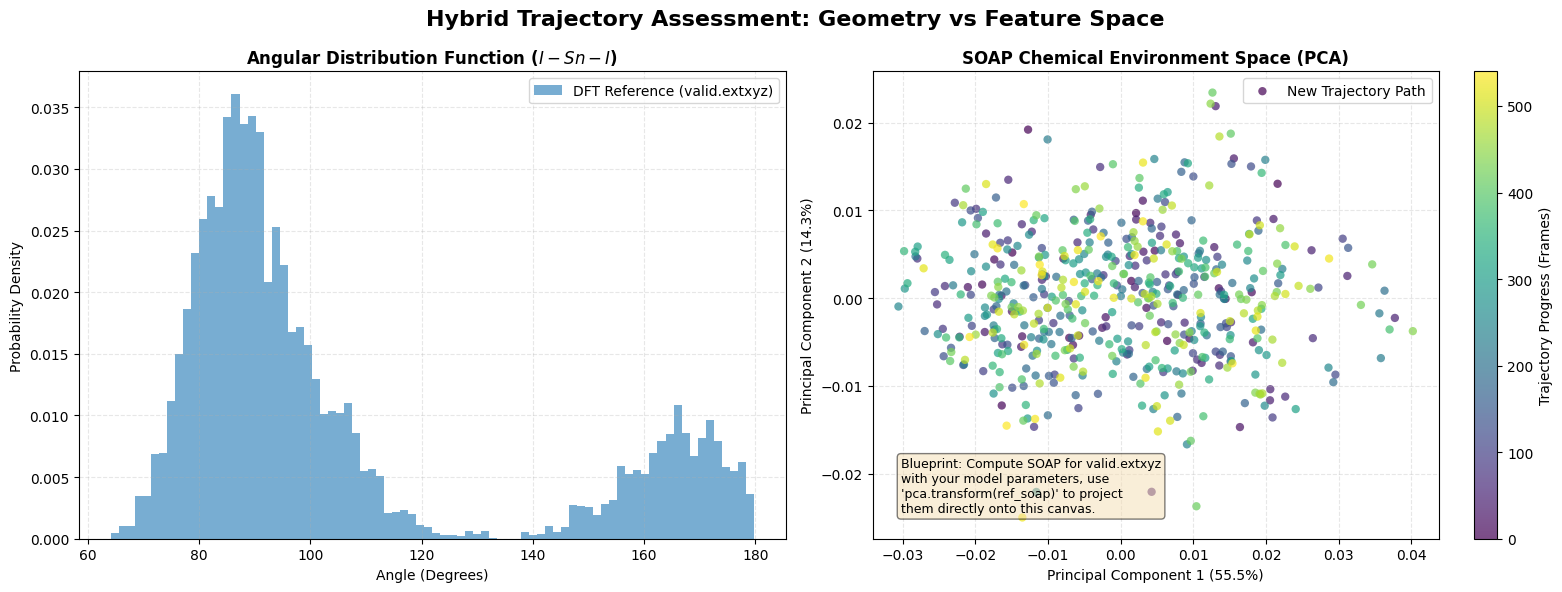

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from ase.io import read
from ase.neighborlist import neighbor_list
from sklearn.decomposition import PCA

# ==============================================================================
# 1. CONFIGURATION AND PATHS
# ==============================================================================
REF_XYZ_PATH = "valid.extxyz"
SOAP_NPY_PATH = "soap_all_atoms_output/soap_all_atoms_shell_3.npy"

# OPTIONAL: If you locate the raw coordinate trajectory file (.extxyz or .xyz)
# that matches your SOAP descriptors, provide its path here to compare angles:
NEW_XYZ_PATH = None  # e.g., "soap_all_atoms_output/new_trajectory.extxyz"


# ==============================================================================
# 2. FUNCTION DEFINITIONS
# ==============================================================================
def compute_triplet_angles(
    frames, center_atom="Sn", neighbor_atom="I", cutoff=3.5
):
    """Computes all neighbor-center-neighbor angles within a given cutoff radius."""
    all_angles = []
    for atoms in frames:
        center_indices = [
            idx for idx, sym in enumerate(atoms.symbols) if sym == center_atom
        ]
        # Build neighbor lists utilizing periodic boundary conditions
        i_idx, j_idx = neighbor_list("ij", atoms, cutoff=cutoff)

        for c in center_indices:
            neighbors = j_idx[
                (i_idx == c)
                & (np.array([atoms.symbols[n] for n in j_idx]) == neighbor_atom)
            ]
            n_neighbors = len(neighbors)
            if n_neighbors < 2:
                continue

            for idx1 in range(n_neighbors):
                for idx2 in range(idx1 + 1, n_neighbors):
                    n1 = neighbors[idx1]
                    n2 = neighbors[idx2]
                    v1 = atoms.get_distance(c, n1, vector=True, mic=True)
                    v2 = atoms.get_distance(c, n2, vector=True, mic=True)

                    cos_theta = np.dot(v1, v2) / (
                        np.linalg.norm(v1) * np.linalg.norm(v2)
                    )
                    cos_theta = np.clip(cos_theta, -1.0, 1.0)
                    all_angles.append(np.degrees(np.arccos(cos_theta)))
    return np.array(all_angles)


# ==============================================================================
# 3. STEP 1: REAL-SPACE STRUCTURAL COMPARISON (ANGLES)
# ==============================================================================
print("--- Step 1: Extracting Real-Space Geometries ---")
print(f"Reading reference structures from {REF_XYZ_PATH}...")
ref_frames = read(REF_XYZ_PATH, index=":")
ref_angles = compute_triplet_angles(
    ref_frames, center_atom="Sn", neighbor_atom="I", cutoff=3.5
)

new_angles = None
if NEW_XYZ_PATH and os.path.exists(NEW_XYZ_PATH):
    print(f"Reading new trajectory structures from {NEW_XYZ_PATH}...")
    new_frames = read(NEW_XYZ_PATH, index=":")
    new_angles = compute_triplet_angles(
        new_frames, center_atom="Sn", neighbor_atom="I", cutoff=3.5
    )
else:
    print(
        "[Info] Skipping new trajectory angle calculation. (To enable, set NEW_XYZ_PATH to a valid coordinates file)"
    )


# ==============================================================================
# 4. STEP 2: FEATURE-SPACE ENVIRONMENT COMPARISON (SOAP)
# ==============================================================================
print("\n--- Step 2: Processing SOAP Descriptor Space ---")
if not os.path.exists(SOAP_NPY_PATH):
    print(f"[Warning] SOAP file not found at: {SOAP_NPY_PATH}")
    soap_data = None
else:
    print(f"Loading SOAP descriptors from {SOAP_NPY_PATH}...")
    soap_data = np.load(SOAP_NPY_PATH, allow_pickle=True)
    print(f"Loaded array shape: {soap_data.shape}")

    # Convert atomic descriptors into global frame descriptors by averaging over all atoms per frame
    if soap_data.ndim == 3:  # Shape: (n_frames, n_atoms, 2325)
        n_frames, n_atoms, n_features = soap_data.shape
        print(
            f"Detected {n_frames} frames with {n_atoms} atoms and {n_features} features."
        )
        # Average across the atom dimension (axis 1) to get 1 structural fingerprint per frame
        global_soap_new = np.mean(soap_data, axis=1)
    elif soap_data.ndim == 2:  # Shape: (total_atoms_flattened, 2325)
        print("Detected flattened atomic SOAP matrix.")
        global_soap_new = soap_data
    else:
        print(f"[Error] Unexpected SOAP array dimension: {soap_data.ndim}")
        global_soap_new = None

    if global_soap_new is not None:
        # Reduce dimensions to 2D using Principal Component Analysis (PCA)
        print("Fitting PCA space to visualize trajectory overlap...")
        pca = PCA(n_components=2)
        pca_new_trajectory = pca.fit_transform(global_soap_new)


# ==============================================================================
# 5. STEP 3: VISUALIZATION PIPELINE
# ==============================================================================
print("\n--- Step 3: Generating Comparison Plots ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Angular Distribution Function
ax_angles = axes[0]
ax_angles.hist(
    ref_angles,
    bins=80,
    density=True,
    alpha=0.6,
    label="DFT Reference (valid.extxyz)",
    color="#1f77b4",
)
if new_angles is not None:
    ax_angles.hist(
        new_angles,
        bins=80,
        density=True,
        alpha=0.6,
        label="New Trajectory (Angles)",
        color="#ff7f0e",
    )
ax_angles.set_title(
    "Angular Distribution Function ($I-Sn-I$)", fontweight="bold"
)
ax_angles.set_xlabel("Angle (Degrees)")
ax_angles.set_ylabel("Probability Density")
ax_angles.grid(True, alpha=0.3, linestyle="--")
ax_angles.legend()

# Plot B: SOAP Feature Space Map (PCA)
ax_soap = axes[1]
if "global_soap_new" in locals() and global_soap_new is not None:
    ax_soap.scatter(
        pca_new_trajectory[:, 0],
        pca_new_trajectory[:, 1],
        c=np.arange(len(pca_new_trajectory)),
        cmap="viridis",
        alpha=0.7,
        edgecolors="none",
        label="New Trajectory Path",
    )
    cbar = plt.colorbar(
        ax_soap.collections[0], ax=ax_soap, label="Trajectory Progress (Frames)"
    )

    # --- Blueprint note for adding Reference SOAP onto this plot ---
    ax_soap.text(
        0.05,
        0.05,
        "Blueprint: Compute SOAP for valid.extxyz\nwith your model parameters, use\n'pca.transform(ref_soap)' to project\nthem directly onto this canvas.",
        transform=ax_soap.transAxes,
        fontsize=9,
        verticalalignment="bottom",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    ax_soap.set_title("SOAP Chemical Environment Space (PCA)", fontweight="bold")
    ax_soap.set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax_soap.set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax_soap.grid(True, alpha=0.3, linestyle="--")
    ax_soap.legend(loc="upper right")
else:
    ax_soap.text(
        0.5,
        0.5,
        "SOAP .npy file not loaded successfully",
        ha="center",
        va="center",
    )
    ax_soap.set_title("SOAP Chemical Environment Space (PCA)")

plt.suptitle(
    "Hybrid Trajectory Assessment: Geometry vs Feature Space",
    fontsize=16,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from ase.io import read
from ase.neighborlist import neighbor_list
from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance  # <--- Crucial for metric calculation
from dscribe.descriptors import SOAP

# ==============================================================================
# 1. CONFIGURATION AND PATHS
# ==============================================================================
REF_XYZ_PATH = "valid.extxyz"
SOAP_NPY_PATH = "soap_all_atoms_output/soap_all_atoms_shell_3.npy"
NEW_XYZ_PATH = "valid.extxyz"  # Set your new trajectory path here to compare angles!

# SOAP Hyperparameters matching your previous run to generate the reference
N_MAX = 6
L_MAX = 4
SIGMA = 0.3
CUTOFF_BUFFER = 0.5
BATCH_SIZE = 2000

# ==============================================================================
# 2. FUNCTION DEFINITIONS
# ==============================================================================
def compute_triplet_angles(frames, center_atom="Sn", neighbor_atom="I", cutoff=3.5):
    """Computes all neighbor-center-neighbor angles within a given cutoff radius."""
    all_angles = []
    for atoms in frames:
        center_indices = [idx for idx, sym in enumerate(atoms.symbols) if sym == center_atom]
        i_idx, j_idx = neighbor_list("ij", atoms, cutoff=cutoff)

        for c in center_indices:
            neighbors = j_idx[(i_idx == c) & (np.array([atoms.symbols[n] for n in j_idx]) == neighbor_atom)]
            n_neighbors = len(neighbors)
            if n_neighbors < 2:
                continue

            for idx1 in range(n_neighbors):
                for idx2 in range(idx1 + 1, n_neighbors):
                    n1 = neighbors[idx1]
                    n2 = neighbors[idx2]
                    v1 = atoms.get_distance(c, n1, vector=True, mic=True)
                    v2 = atoms.get_distance(c, n2, vector=True, mic=True)

                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    cos_theta = np.clip(cos_theta, -1.0, 1.0)
                    all_angles.append(np.degrees(np.arccos(cos_theta)))
    return np.array(all_angles)

def analyze_atom_distances_batched(trajectory_coords, batch_size=1000):
    num_frames, num_atoms, _ = trajectory_coords.shape
    top10_instantaneous_sum = np.zeros((num_atoms, 10))
    for i in range(0, num_frames, batch_size):
        batch = trajectory_coords[i : i + batch_size]
        diff = batch[:, :, np.newaxis, :] - batch[:, np.newaxis, :, :]
        dist = np.linalg.norm(diff, axis=-1)
        dist[:, np.arange(num_atoms), np.arange(num_atoms)] = np.inf
        sorted_dist = np.sort(dist, axis=-1)
        top10_instantaneous_sum += np.sum(sorted_dist[:, :, :10], axis=0)
    return top10_instantaneous_sum / num_frames

# ==============================================================================
# 3. STEP 1: REAL-SPACE STRUCTURAL COMPARISON (ANGLES)
# ==============================================================================
print("--- Step 1: Extracting Real-Space Geometries ---")
ref_frames = read(REF_XYZ_PATH, index=":")
ref_angles = compute_triplet_angles(ref_frames, center_atom="Sn", neighbor_atom="I", cutoff=3.5)

atom_species = ref_frames[0].get_chemical_symbols()
num_atoms = len(atom_species)
unique_species = sorted(list(set(atom_species)))
is_periodic = any(ref_frames[0].pbc)

new_angles = None
angle_similarity_score = None

if NEW_XYZ_PATH and os.path.exists(NEW_XYZ_PATH):
    print(f"Reading new trajectory structures from {NEW_XYZ_PATH}...")
    new_frames = read(NEW_XYZ_PATH, index=":")
    new_angles = compute_triplet_angles(new_frames, center_atom="Sn", neighbor_atom="I", cutoff=3.5)

    # Quantitative Metric: Earth Mover's (Wasserstein) Distance
    angle_similarity_score = wasserstein_distance(ref_angles, new_angles)
    print(f"-> Angular Distribution Wasserstein Distance: {angle_similarity_score:.4f} degrees")
else:
    print("[Info] Skipping angle similarity calculation (NEW_XYZ_PATH missing).")

# ==============================================================================
# 4. STEP 2: FEATURE-SPACE ALIGNMENT AND OVERLAP (SOAP)
# ==============================================================================
print("\n--- Step 2: Processing SOAP Descriptor Space ---")
if not os.path.exists(SOAP_NPY_PATH):
    print(f"[Warning] SOAP file not found at: {SOAP_NPY_PATH}")
    global_soap_new = None
else:
    print(f"Loading New Trajectory SOAP descriptors from {SOAP_NPY_PATH}...")
    soap_data = np.load(SOAP_NPY_PATH, allow_pickle=True)

    # Properly reshape flattened atomic matrix back to frame-by-frame averages
    if soap_data.ndim == 2:
        n_features = soap_data.shape[1]
        # Reshape to (n_frames, n_atoms, n_features) then average across atoms (axis 1)
        global_soap_new = soap_data.reshape(-1, num_atoms, n_features).mean(axis=1)
    else:
        global_soap_new = np.mean(soap_data, axis=1) if soap_data.ndim == 3 else None

    if global_soap_new is not None:
        print("Generating matching SOAP descriptors for Reference Trajectory...")
        # Re-verify shell 3 r_cut parameter from reference coordinates
        ref_coords = np.array([f.get_positions() for f in ref_frames])
        top10_inst = analyze_atom_distances_batched(ref_coords, batch_size=BATCH_SIZE)
        global_shell_averages = np.mean(top10_inst, axis=0)
        r_cut = global_shell_averages[2] + CUTOFF_BUFFER # Shell 3

        soap_generator = SOAP(
            species=unique_species, r_cut=r_cut, n_max=N_MAX, l_max=L_MAX, sigma=SIGMA, periodic=is_periodic, sparse=False
        )

        all_atom_indices = list(range(num_atoms))
        ref_soap_raw = soap_generator.create(ref_frames, centers=[all_atom_indices] * len(ref_frames))
        global_soap_ref = ref_soap_raw.reshape(-1, num_atoms, ref_soap_raw.shape[1]).mean(axis=1)

        # COMBINED ALIGNED PCA SPACE
        print("Fitting shared PCA canvas using Reference baseline...")
        pca = PCA(n_components=2)
        pca_ref = pca.fit(global_soap_ref) # Fit on reference matrix

        # Project BOTH onto the identical coordinate system
        coords_ref_pca = pca_ref.transform(global_soap_ref)
        coords_new_pca = pca_ref.transform(global_soap_new)

        # Quantitative Metric: Euclidean Distance between Chemical Centroids
        centroid_ref = np.mean(coords_ref_pca, axis=0)
        centroid_new = np.mean(coords_new_pca, axis=0)
        soap_centroid_distance = np.linalg.norm(centroid_ref - centroid_new)
        print(f"-> SOAP Space Centroid Distance: {soap_centroid_distance:.4f} units")

# ==============================================================================
# 5. STEP 3: VISUALIZATION PIPELINE
# ==============================================================================
print("\n--- Step 3: Generating Comparison Plots ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Angular Distribution Function
ax_angles = axes[0]
ax_angles.hist(ref_angles, bins=80, density=True, alpha=0.5, label="DFT Reference Baseline", color="#1f77b4")
if new_angles is not None:
    ax_angles.hist(new_angles, bins=80, density=True, alpha=0.5, label="New Trajectory Path", color="#ff7f0e")
    ax_angles.text(0.05, 0.92, f"Wasserstein Dist: {angle_similarity_score:.4f}°",
                  transform=ax_angles.transAxes, bbox=dict(facecolor='white', alpha=0.7))

ax_angles.set_title("Angular Distribution Function ($I-Sn-I$)", fontweight="bold")
ax_angles.set_xlabel("Angle (Degrees)")
ax_angles.set_ylabel("Probability Density")
ax_angles.grid(True, alpha=0.3, linestyle="--")
ax_angles.legend()

# Plot B: Shared SOAP Feature Space Map (PCA Overlap)
ax_soap = axes[1]
if 'global_soap_new' in locals() and global_soap_new is not None:
    # Plot reference configuration space as a subtle gray shadow/path
    ax_soap.scatter(coords_ref_pca[:, 0], coords_ref_pca[:, 1], color="gray", alpha=0.3, label="Reference Envelope", edgecolors="none")
    ax_soap.plot(coords_ref_pca[:, 0], coords_ref_pca[:, 1], color="gray", alpha=0.2, linestyle="-")

    # Plot new trajectory on top using a color map
    scatter_new = ax_soap.scatter(coords_new_pca[:, 0], coords_new_pca[:, 1], c=np.arange(len(coords_new_pca)),
                                  cmap="plasma", alpha=0.8, edgecolors="none", label="New Trajectory")

    cbar = plt.colorbar(scatter_new, ax=ax_soap, label="Trajectory Progress (Frames)")

    # Annotate Centroid Metric
    ax_soap.text(0.05, 0.05, f"Shared SOAP Canvas\nCentroid Distance: {soap_centroid_distance:.4f}",
                  transform=ax_soap.transAxes, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7))

    ax_soap.set_title("SOAP Chemical Environment Space Alignment", fontweight="bold")
    ax_soap.set_xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax_soap.set_ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax_soap.grid(True, alpha=0.3, linestyle="--")
    ax_soap.legend(loc="upper right")

plt.suptitle("Quantitative Hybrid Trajectory Similarity Assessment", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

--- Step 1: Extracting Real-Space Geometries ---
Reading new trajectory structures from valid.extxyz...
-> Angular Distribution Wasserstein Distance: 0.0000 degrees

--- Step 2: Processing SOAP Descriptor Space ---
Loading New Trajectory SOAP descriptors from soap_all_atoms_output/soap_all_atoms_shell_3.npy...
Generating matching SOAP descriptors for Reference Trajectory...
